# 0. 환경설정

In [183]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

# 1. Fashion_mnist

## 1. 데이터 불러오기

In [43]:
# 실습 1-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


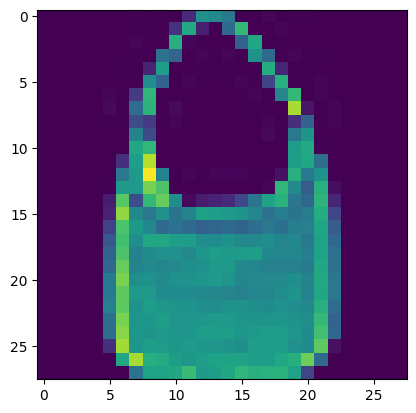

8


In [44]:
# 실습 1-1 데이터 확인

idx = np.random.randint(60000)   # 6만개 중 랜덤으로 하나 뽑기
plt.imshow(x_train[idx])         # 해당 위치 Train 데이터 확인
plt.show()
print(y_train[idx])              # 해당되는 타겟데이터 확인

## 2. 전처리

In [45]:
# 실습 2-1 차원 일치 : Dense 는 1차원 데이터만 받을 수 있음

x_train_1d = x_train.reshape(60000,-1)   # 60000 제외 곱하기(1차원 조정)
x_test_1d = x_test.reshape(10000,-1)     # 10000 제외 곱하기(1차원 조정)
print(x_train_1d.shape, x_test_1d.shape) # 28*28 = 784

(60000, 784) (10000, 784)


In [46]:
# 실습 2-2 전처리 필요 여부 확인

print(np.min(x_train_1d), np.max(x_train_1d))

0 255


In [47]:
# 실습 2-3 전처리
# 0~255 라서 255로 나눠주면 Min-Max 가 됨

x_train_1d = x_train.reshape(60000,-1) / 255
x_test_1d = x_test.reshape(10000,-1) / 255
print(x_train_1d.shape, x_test_1d.shape)

(60000, 784) (10000, 784)


In [48]:
# 실습 2-4 전처리 결과

print(np.min(x_train_1d), np.max(x_train_1d))

0.0 1.0


In [49]:
# 실습 2-5 one-hot encoding을 하기 위해 속성 수 확인

print(np.unique(y_test, return_counts=True))  # 1000개씩 10개 속성

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))


In [50]:
# 실습 2-6 one-hot encoding 처리

y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)
print(y_train_oh.shape, y_test_oh.shape)

(60000, 10) (10000, 10)


## 3. 모델 학습

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7885 - loss: 0.5854 - val_accuracy: 0.8423 - val_loss: 0.4308
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8391 - loss: 0.4433 - val_accuracy: 0.8461 - val_loss: 0.4139
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8504 - loss: 0.4085 - val_accuracy: 0.8529 - val_loss: 0.3854
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8601 - loss: 0.3830 - val_accuracy: 0.8632 - val_loss: 0.3655
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8663 - loss: 0.3673 - val_accuracy: 0.8687 - val_loss: 0.3582
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8684 - loss: 0.3555 - val_accuracy: 0.8684 - val_loss: 0.3595
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8732 - loss: 0.3464 - val_accuracy: 0.8746 - val_loss: 0.3561
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8756 - loss: 0

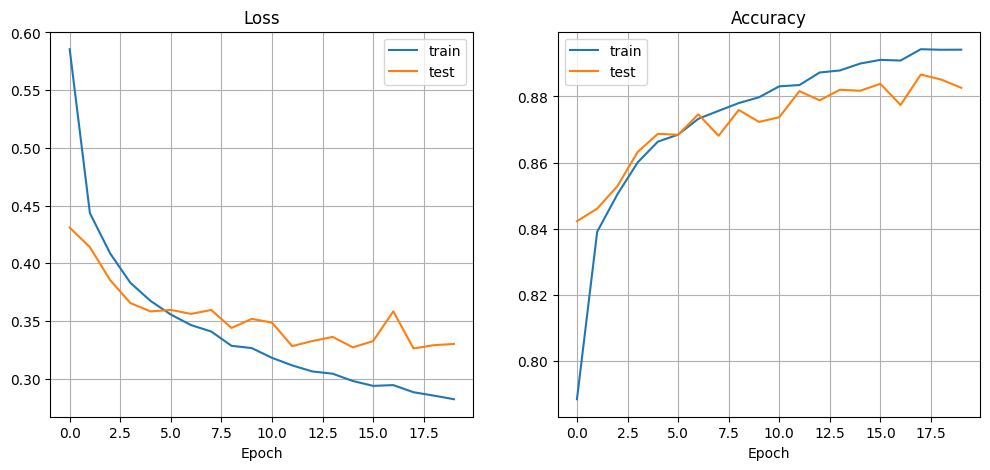

In [52]:
# 실습 3-1 모델 설정

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(256, activation='relu'))   # 입력 차원(784)보다 줄이되 정보 손실이 크지 않도록 약 1/3 크기로 시작합니다
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))   # 각 층이 이전 층 정보를 완만하게 압축·재조합
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax')) # 원핫 인코딩이니 확률값(softmax)으로 출력
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_1d, y_train_oh,                 # 훈련 데이터
                 validation_data=(x_test_1d, y_test_oh), # 테스트 데이터
                 epochs=20)


def learning_plot(hist):
    plt.figure(figsize=(12, 5))

    # 오차(Loss) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Loss')
    plt.xlabel('Epoch')

    # 정확도(Accuracy) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Accuracy')
    plt.xlabel('Epoch')

    plt.show()

learning_plot(hist)

In [53]:
# 실습 3-2 테스트 accuracy 확인

test_loss, test_acc = model.evaluate(x_test_1d, y_test_oh)
print( test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8826 - loss: 0.3300
테스트 accuracy: 0.8826000094413757


# 2. Fetch_lfw_people 데이터 실습

## 1. 데이터 불러오기

(1140, 62, 47)
['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


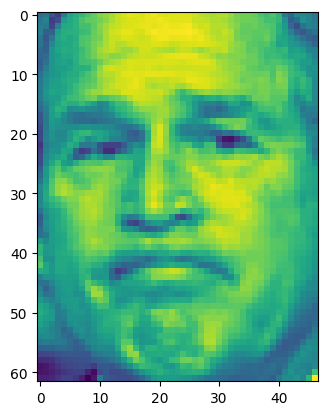

In [181]:
# 실습 1-0 데이터 불러오기

data = fetch_lfw_people(min_faces_per_person=100)  # 100장 이상 사진의 사람만
print(data.images.shape)                           # 개수 / 62*47 사진
print(data.target_names)                           # 100장 이상인 사람 이름
plt.imshow(data.images[0])
plt.show()


In [70]:
# 실습 1-1 전처리 필요성 확인

print(np.min(data.images), np.max(data.images)) # 전처리 되어 있음

0.0 1.0


## 2. 전처리

In [63]:
# 실습 2-1 전처리

x_data = data.images.reshape(1140, -1)  # 데이터 차원 변경(62*47 = 2914)
y_data = to_categorical(data.target)    # 원핫 인코딩(5명)

print(x_data.shape, y_data.shape)

(1140, 2914) (1140, 5)


In [64]:
# 실습 2-2 모델 설계 준비

np.unique(data.target, return_counts=True) # 정답 유형과 개수

(array([0, 1, 2, 3, 4]), array([236, 121, 530, 109, 144]))

In [66]:
# 실습 2-3 데이터 분리

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
                                                    stratify=y_data,
                                                    random_state=260710)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(855, 2914) (285, 2914)
(855, 5) (285, 5)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 1024)           │     2,984,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,288,837 (12.55 MB)

 Trainable params: 3,288,837 (12.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.4094 - loss: 1.7563 - val_accuracy: 0.4667 - val_loss: 1.4264
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4433 - loss: 1.4957 - val_accuracy: 0.4667 - val_loss: 1.5050
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4585 - loss: 1.3923 - val_accuracy: 0.4842 - val_loss: 1.3340
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5205 - loss: 1.2899 - val_accuracy: 0.5298 - val_loss: 1.2123
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5497 - loss: 1.1788 - val_accuracy: 0.5193 - val_loss: 1.1670
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5778 - loss: 1.1179 - val_accuracy: 0.5018 - val_loss: 1.3122
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5567 - loss: 1.1420 - val_accuracy: 0.6070 - val_loss: 0.9718
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6491 - loss: 0.9177 - val_accuracy: 0.7018 - v

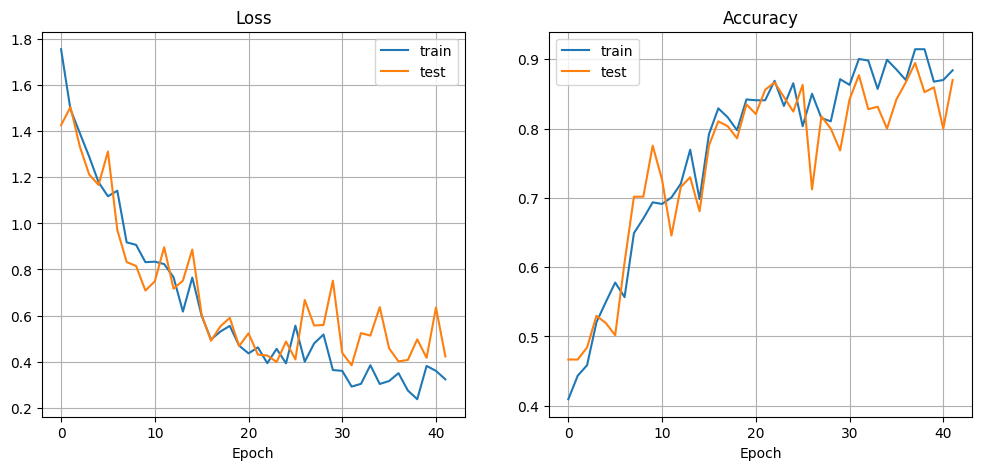

In [73]:
# 2-4 모델 설계

model = Sequential()
model.add(Input(shape=(2914,)))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax'))
model.summary()
esc = EarlyStopping(monitor= 'val_loss', patience= 10) # 오버피팅되면 자동으로 종료

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, callbacks=[esc])

learning_plot(hist)

In [78]:
# 실습 2-5 얼마나 예측하는지 확인

pred = model.predict(x_test)
confusion_matrix(np.argmax(y_test, axis = 1), np.argmax(pred, axis=1))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[ 54,   0,   4,   1,   0],
       [  5,  22,   3,   0,   0],
       [  4,   1, 126,   2,   0],
       [  1,   0,   1,  25,   0],
       [  3,   1,   4,   7,  21]])

# 3. 사진 비교하기 실습

## 1. 불러오기

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/bb_01.jpg
(100, 100)


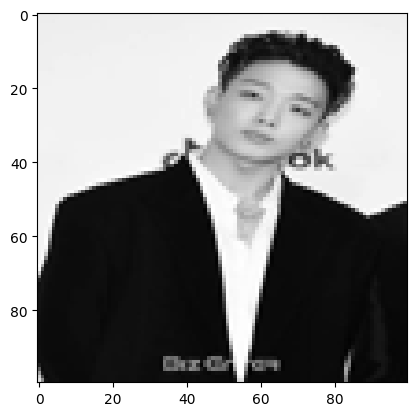

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/hc_01.jpg
(100, 100)


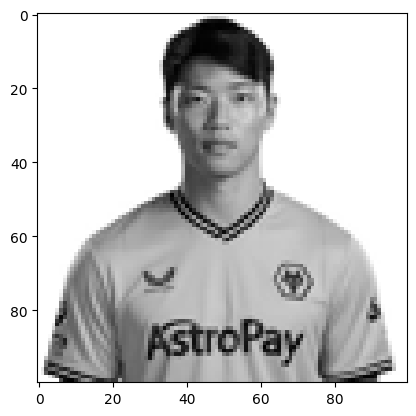

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/pk_02.jpg
(100, 100)


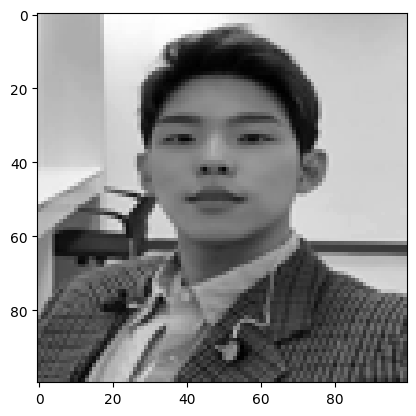

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/pk_05.jpg
(100, 100)


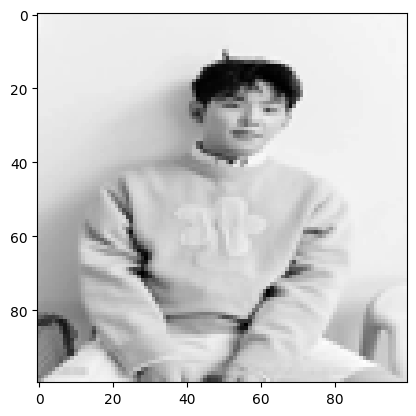

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/pk_04.jpg
(100, 100)


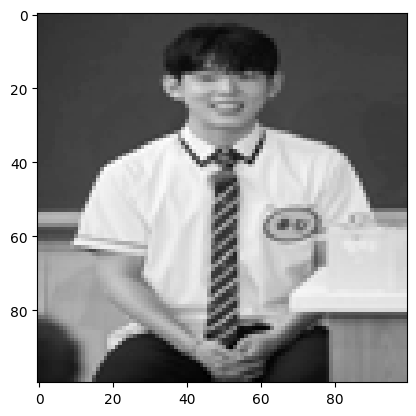

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/pk_01.jpg
(100, 100)


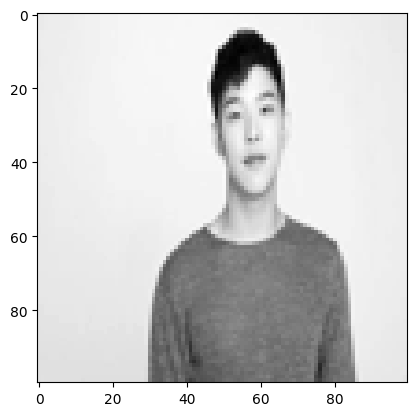

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/pk_03.jpg
(100, 100)


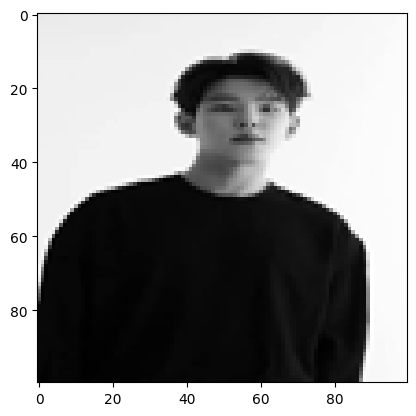

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/hc_04.jpg
(100, 100)


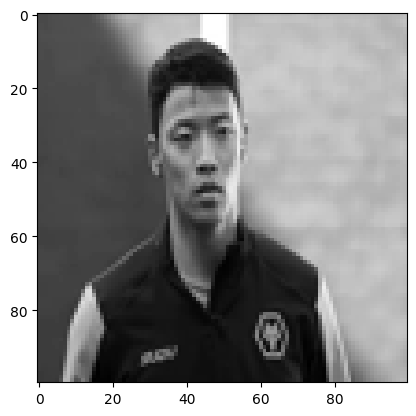

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/hc_02.jpg
(100, 100)


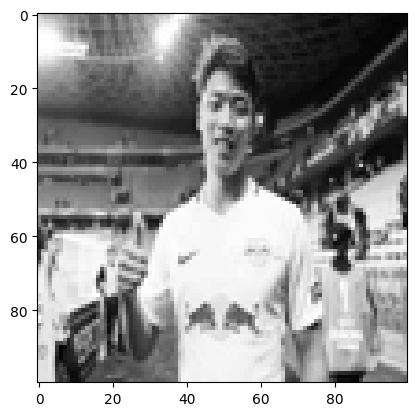

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/bb_02.jpg
(100, 100)


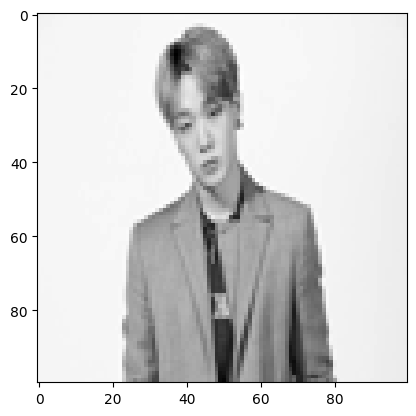

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/bb_03.jpg
(100, 100)


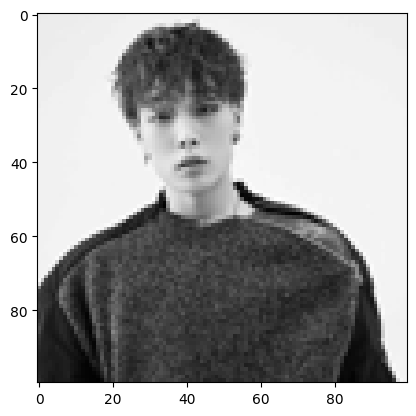

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/hc_05.jpg
(100, 100)


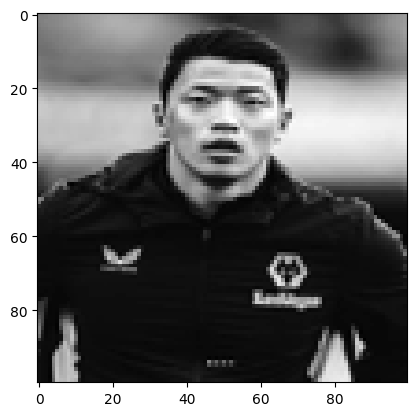

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/bb_04.jpg
(100, 100)


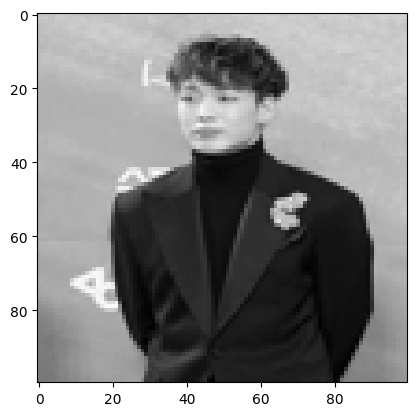

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/hc_03.jpg
(100, 100)


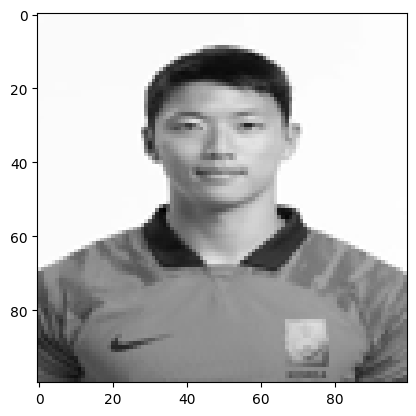

/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/bb_05.jpg
(100, 100)


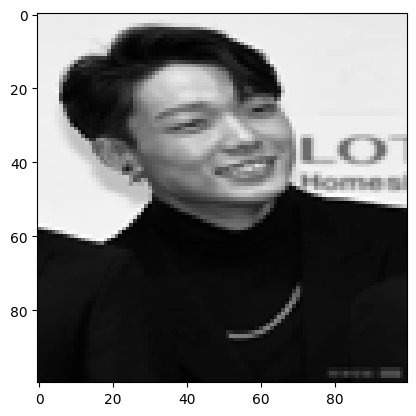

(15, 100, 100)
[0 1 2 2 2 2 2 1 1 0 0 1 0 1 0]


In [184]:
# 실습 1-0 불러오기

root = "/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05"

x_data = []  # 원본 값
y_data = []  # 라벨 값

for fn in glob.glob(root + "/*.jpg"):
  print(fn)
  if fn.split('/')[-1].startswith('bb'):
    y_data.append(0)
  elif fn.split('/')[-1].startswith('hc'):
    y_data.append(1)
  elif fn.split('/')[-1].startswith('pk'):
    y_data.append(2)
  else:
    print('error')

  img = Image.open(fn).convert('L')    # 이미지 불러오고, 흑백 변환
  img = img.resize((100,100))          # 사이즈 조정(100*100)
  ndimg = np.array(img)                # nd array(그림 형태를 숫자형태)로 전환
  x_data.append(ndimg)                 # 원본값에 추가하기
  print(ndimg.shape)                   # 원본값 모양 확인
  plt.imshow(ndimg, cmap='grey')       # 이미지 보여주기
  plt.show()

x_data = np.array(x_data)
y_data = np.array(y_data)
print(x_data.shape)
print(y_data)

In [185]:
# 실습 1-1 데이터 전처리 필요 여부 확인

print(np.min(x_data), np.max(x_data))

0 255


In [186]:
# 실습 1-2 데이터 전처리 후 분리

x = x_data.reshape(15,-1) / 255 # 차원 조정 및 전처리
y = to_categorical(y_data)      # one-hot encoding 처리
print(x.shape, y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    stratify=y_data,
                                                    test_size=0.2,
                                                    random_state=260710)

print(x_test.shape)
print(x_train.shape)
print(y_test.shape)
print(y_train.shape)

(15, 10000) (15, 3)
(3, 10000)
(12, 10000)
(3, 3)
(12, 3)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 1024)           │    10,241,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,520,067 (40.13 MB)

 Trainable params: 10,520,067 (40.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.2580 - val_accuracy: 0.3333 - val_loss: 14.5115
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - accuracy: 0.3333 - loss: 13.2013 - val_accuracy: 0.3333 - val_loss: 11.4788
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.3333 - loss: 14.5195 - val_accuracy: 0.3333 - val_loss: 5.6921
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.3333 - loss: 9.0016 - val_accuracy: 0.3333 - val_loss: 3.4851
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step - accuracy: 0.3333 - loss: 5.2838 - val_accuracy: 0.3333 - val_loss: 1.5716
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.4167 - loss: 1.3606 - val_accuracy: 0.3333 - val_loss: 4.9954
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.3333 - loss: 4.7576 - val_accuracy: 0.3333 - val_loss: 4.2146
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.3333 - loss: 4.6145 - val_accuracy: 0.6667 - val_loss

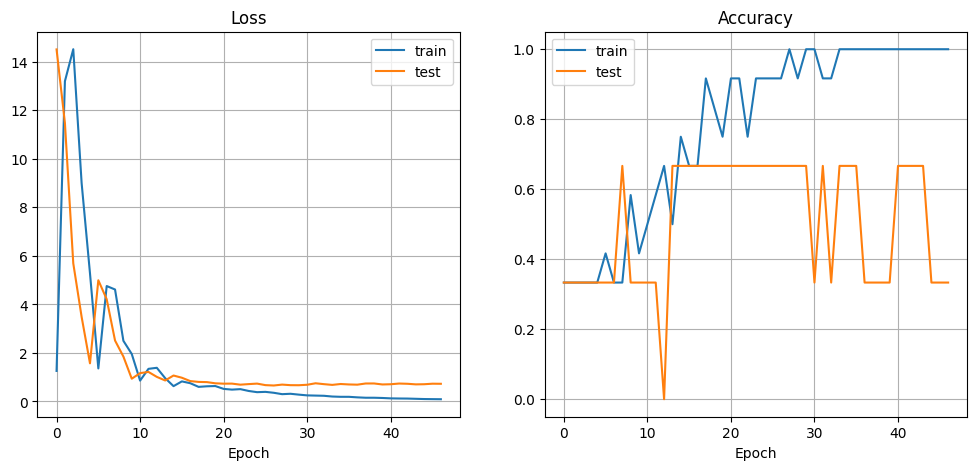

In [187]:
# 실습 1-3 모델 설계

model = Sequential()
model.add(Input(shape=(10000,)))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()
esc = EarlyStopping(monitor= 'val_loss', patience= 20)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, callbacks=[esc])

learning_plot(hist)

In [188]:
# 실습 1-4 테스트 데이터로 예측 잘하는 지 확인

pred = model.predict(x_test)
y_test, pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


(array([[0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]]),
 array([[0.0294947 , 0.40464917, 0.56585616],
        [0.81051147, 0.1843611 , 0.00512745],
        [0.07924935, 0.57690746, 0.34384322]], dtype=float32))

## 2. 사진으로 테스트하기

In [189]:
# 실습 2-1 학습모델 불러오기

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 1024)           │    10,241,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,560,203 (120.39 MB)

 Trainable params: 10,520,067 (40.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,040,136 (80.26 MB)

(100, 100)


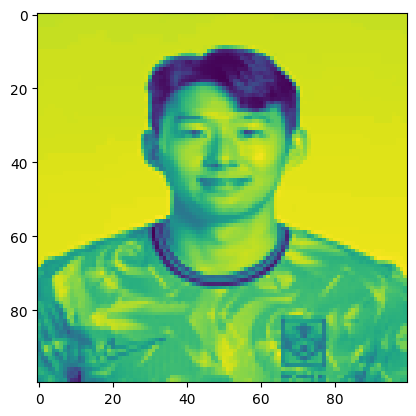

(1, 10000)


In [190]:
# 실습 2-2 사진 불러오기

root = "/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/Test/hm.jpg"

img = Image.open(root).convert('L')
img = img.resize((100,100))
ndimg = np.array(img)
print(ndimg.shape)

plt.imshow(ndimg)
plt.show()
                        # (1,100,100)   # (1,10000)
x_data = np.array(ndimg)[np.newaxis, :].reshape(1,-1) / 255   # Min-Max
print(x_data.shape)

In [191]:
# 실습 2-3 예측하기

pred = model.predict(x_data)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0.11007578 0.79975104 0.09017308]]


# 4.Mnist 실습

## 1. 데이터 불러오기

In [167]:
# 실습 1-0 테이터 불러오기

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000,)


In [168]:
# 실습 1-1 입력 데이터 전처리
# 1차원으로 조정하고 Min-Max 적용

x_train_1d = x_train.reshape(60000,-1) /255
x_test_1d = x_test.reshape(10000,-1) / 255
print(x_train_1d.shape, x_test_1d.shape)

(60000, 784) (10000, 784)


In [179]:
# 실습 1-2 Target 데이터 전처리
# One-Hot encoding

y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)
print(y_train_oh.shape, y_test_oh.shape)

(60000, 10) (10000, 10)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - accuracy: 0.9355 - loss: 0.2122 - val_accuracy: 0.9641 - val_loss: 0.1237
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9717 - loss: 0.0922 - val_accuracy: 0.9715 - val_loss: 0.0973
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.9794 - loss: 0.0658 - val_accuracy: 0.9763 - val_loss: 0.0810
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9844 - loss: 0.0484 - val_accuracy: 0.9768 - val_loss: 0.0755
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9873 - loss: 0.0403 - val_accuracy: 0.9783 - val_loss: 0.0775
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9884 - loss: 0.0357 - val_accuracy: 0.9784 - val_loss: 0.0783
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9789 - val_loss: 0.0822
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9

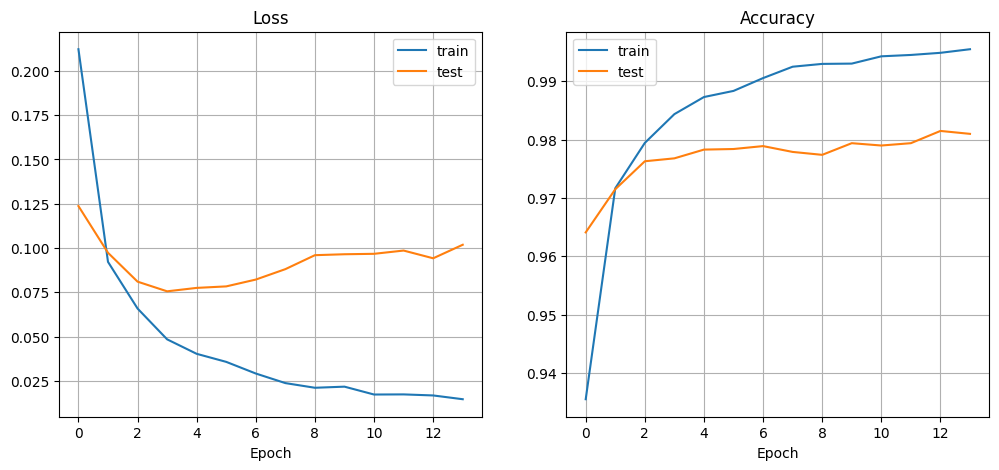

In [171]:
# 실습 1-3 모델 설계

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()
esc = EarlyStopping(monitor= 'val_loss', patience= 10) # 오버피팅되면 종료 설정

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_1d, y_train_oh,
                 validation_data=(x_test_1d, y_test_oh),
                 epochs=100, callbacks=[esc])

learning_plot(hist)

(28, 28) 255


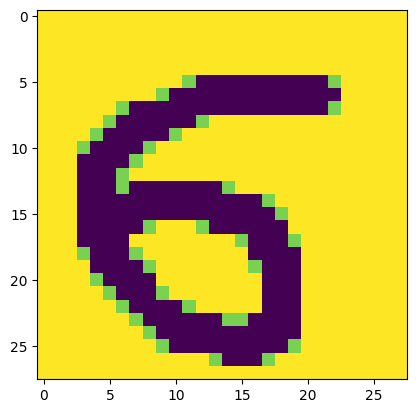

(1, 784) 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
[[1.0600296e-21 2.2173007e-24 3.0926761e-13 2.0182456e-07 1.2016293e-28
  9.9863511e-01 3.3433891e-23 1.3646865e-03 3.8295696e-11 4.0569128e-20]]


In [175]:
# 실습 1-4 예측할 자료 불러오기

root = "/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/6.png"

img = Image.open(root).convert('L')    # 이미지 파일로 올리기
img = img.resize((28,28))              # 28,28으로 사이즈 조정
ndimg = np.array(img)                  # 넘파이로 조정
print(ndimg.shape, np.max(ndimg))      # Shape 확인 및 최댓값(RGB 형식) 확인

plt.imshow(ndimg)                      # 이미지 확인
plt.show()
            # 차원 조정     (1,784)로 조정  MinMax
x_data = ndimg.reshape(-1)[np.newaxis,:] / 255
print(x_data.shape, np.max(x_data))

pred = model.predict(x_data)                  # 예측 돌리기
print(pred)

In [176]:
# 실습 1-5 유의
# test 는 흰색이 1이 되고, train은 검은색이 0인 상태

x_data[0]

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

(28, 28) 255


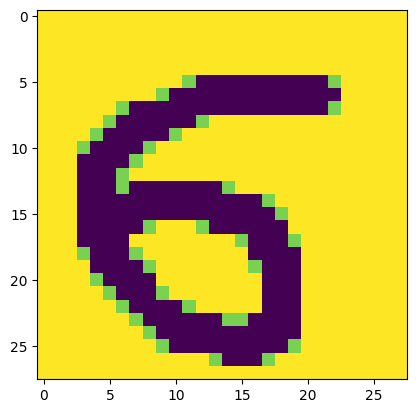

(1, 784) 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[3.1330148e-07 3.4186865e-08 1.4253788e-01 1.1985379e-01 8.4059673e-07
  2.5188830e-01 1.7250599e-07 1.0998830e-05 1.7301060e-01 3.1269708e-01]]


In [178]:
# 실습 1-6 색 반전

root = "/content/drive/MyDrive/Colab Notebooks/07 딥러닝/Day_05/6.png"

img = Image.open(root).convert('L')
img = img.resize((28,28))
ndimg = np.array(img)
print(ndimg.shape, np.max(ndimg))

plt.imshow(ndimg)
plt.show()
      # 색반전
x_data = 1 - (ndimg.reshape(-1)[np.newaxis,:] / 255)
print(x_data.shape, np.max(x_data))

pred = model.predict(x_data)
print(pred)